# Load data from InfluxDB

In [312]:
%pip install influxdb-client


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [313]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "nIFNlhkdcuc8p7zn-zR5X0aHrMUhzEKEmcsne4YRugOvoWBTgzpeSl2SsBJp8buZJ-wR9jRXVzL7py6v23_KMw=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [314]:
# 1. Define the dynamic variables in the params dictionary
time_start = "-24h"
time_stop = "now()"
window = "1s"

# 2. Define the query using the v.variable syntax
query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-5]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_ctrl_msgs = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
'''

# 3. Execute and return as a DataFrame
df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_ctrl_msgs = query_api.query_data_frame(query_ctrl_msgs)




/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ur3e")
  |> range(start: -24h, stop: now())
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/inf

# Show data

In [315]:
print(df_ctrl_msgs.head())

    result  table                           _start  \
0  _result      0 2026-03-05 15:32:50.768608+00:00   
1  _result      0 2026-03-05 15:32:50.768608+00:00   
2  _result      0 2026-03-05 15:32:50.768608+00:00   
3  _result      0 2026-03-05 15:32:50.768608+00:00   
4  _result      0 2026-03-05 15:32:50.768608+00:00   

                             _stop                            _time _value  \
0 2026-03-06 15:32:50.768608+00:00 2026-03-06 14:32:13.106679+00:00   play   
1 2026-03-06 15:32:50.768608+00:00 2026-03-06 14:33:53.088564+00:00   play   
2 2026-03-06 15:32:50.768608+00:00 2026-03-06 14:35:33.088458+00:00   play   
3 2026-03-06 15:32:50.768608+00:00 2026-03-06 14:37:13.090143+00:00   play   
4 2026-03-06 15:32:50.768608+00:00 2026-03-06 14:38:53.095421+00:00   play   

     _field _measurement msg_type                 source  
0  msg_type    ctrl_msgs     play  data_recorder_service  
1  msg_type    ctrl_msgs     play  data_recorder_service  
2  msg_type    ctrl_msgs     

In [316]:
print(df_sensor_data.head())


    result  table                            _time  \
0  _result      0 2026-03-06 14:31:55.727094+00:00   
1  _result      0 2026-03-06 14:31:55.796400+00:00   
2  _result      0 2026-03-06 14:31:55.830380+00:00   
3  _result      0 2026-03-06 14:31:55.879379+00:00   
4  _result      0 2026-03-06 14:31:55.932565+00:00   

                            _start                            _stop  \
0 2026-03-05 15:32:49.518085+00:00 2026-03-06 15:32:49.518085+00:00   
1 2026-03-05 15:32:49.518085+00:00 2026-03-06 15:32:49.518085+00:00   
2 2026-03-05 15:32:49.518085+00:00 2026-03-06 15:32:49.518085+00:00   
3 2026-03-05 15:32:49.518085+00:00 2026-03-06 15:32:49.518085+00:00   
4 2026-03-05 15:32:49.518085+00:00 2026-03-06 15:32:49.518085+00:00   

  _measurement                 source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  data_recorder_service     -5.996181e-09             -1.57   
1  sensor_data  data_recorder_service      1.521799e-07             -1.57   
2  sensor_data  d

In [317]:
sensor_data_np = df_sensor_data.to_numpy()
start_msgs_timestamps = df_ctrl_msgs["_time"].to_list()

In [318]:
sensor_data_np.shape

(72759, 19)

In [319]:
sensor_data_np[0, :]

array(['_result', 0,
       Timestamp('2026-03-06 14:31:55.727094+0000', tz='UTC'),
       Timestamp('2026-03-05 15:32:49.518085+0000', tz='UTC'),
       Timestamp('2026-03-06 15:32:49.518085+0000', tz='UTC'),
       'sensor_data', 'data_recorder_service', -5.99618077182635e-09,
       -1.5699999699668743, 1.5699998694178776, -1.5699999462566772,
       -1.5699999542730279, 3.3311187879764153e-09, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0], dtype=object)

In [320]:
start_msgs_timestamps

[Timestamp('2026-03-06 14:32:13.106679+0000', tz='UTC'),
 Timestamp('2026-03-06 14:33:53.088564+0000', tz='UTC'),
 Timestamp('2026-03-06 14:35:33.088458+0000', tz='UTC'),
 Timestamp('2026-03-06 14:37:13.090143+0000', tz='UTC'),
 Timestamp('2026-03-06 14:38:53.095421+0000', tz='UTC'),
 Timestamp('2026-03-06 14:40:33.096457+0000', tz='UTC'),
 Timestamp('2026-03-06 14:42:13.098364+0000', tz='UTC'),
 Timestamp('2026-03-06 14:43:53.102335+0000', tz='UTC'),
 Timestamp('2026-03-06 14:45:33.102860+0000', tz='UTC'),
 Timestamp('2026-03-06 14:47:13.108186+0000', tz='UTC'),
 Timestamp('2026-03-06 14:48:53.106433+0000', tz='UTC'),
 Timestamp('2026-03-06 14:50:33.111172+0000', tz='UTC'),
 Timestamp('2026-03-06 14:52:13.113143+0000', tz='UTC'),
 Timestamp('2026-03-06 14:53:53.114986+0000', tz='UTC'),
 Timestamp('2026-03-06 14:55:33.118540+0000', tz='UTC'),
 Timestamp('2026-03-06 14:57:13.124316+0000', tz='UTC'),
 Timestamp('2026-03-06 14:58:53.118760+0000', tz='UTC'),
 Timestamp('2026-03-06 15:00:33

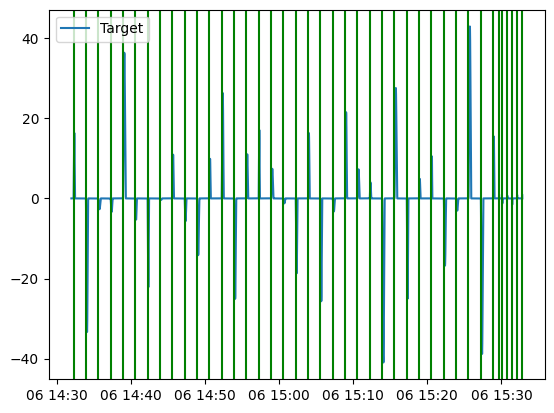

In [321]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, 2], sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for movement_start in start_msgs_timestamps:
    plt.axvline(movement_start, color="g")

plt.legend()

# Determine end of movements
From observing the PT mockup, we have determined that all joints take the same amount of time to move.

In [322]:
import copy
# Translate timestamps into indexes
start_indexes = []
start_timestamps = copy.deepcopy(start_msgs_timestamps)

for n in range(sensor_data_np.shape[0] - 1):
    time_at_n = sensor_data_np[n, 2]
    time_at_n_plus_1 = sensor_data_np[n+1, 2]
    if time_at_n <= start_timestamps[0] <= time_at_n_plus_1:
        start_indexes.append(n)
        start_timestamps.pop(0)
    if len(start_timestamps) == 0:
        break

In [323]:
start_indexes

[346,
 2337,
 4328,
 6320,
 8311,
 10303,
 12295,
 14286,
 16278,
 18268,
 20260,
 22251,
 24241,
 26231,
 28221,
 30213,
 32205,
 34196,
 36189,
 38182,
 40172,
 42163,
 44153,
 46144,
 48136,
 50128,
 52118,
 54109,
 56102,
 58093,
 60084,
 62077,
 64067,
 66058,
 68028,
 68991,
 69520,
 70318,
 71114,
 71910,
 72706]

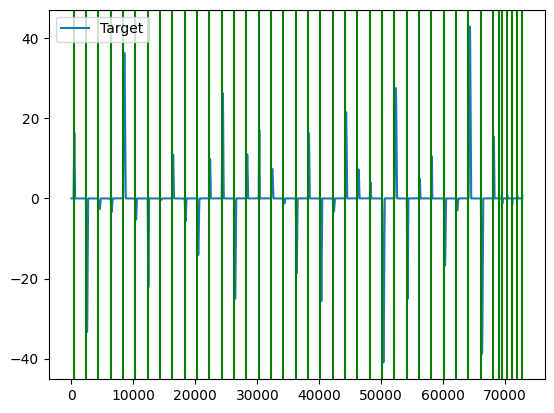

In [324]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i in start_indexes:
    plt.axvline(i, color="g")

plt.legend()

In [325]:
def determine_movement_ends(joint_vels: np.ndarray, start_indexes: list, threshold=1e-3, window=5):
    end_timestamps = []
    
    # Combine into a single speed since every joint finishes moving at the same time
    speed = np.linalg.norm(joint_vels, axis=1)
    
    for i in start_indexes:
        # Only look at data occurring after the start of this specific movement
        post_start_speed = speed[i:]
        
        # Find where speed drops below the threshold
        under_threshold = post_start_speed < threshold
        
        # To avoid mid-motion zero-crossings, ensure speed stays low for 'window' frames
        # We use a logical convolution to find a sequence of 'True' values
        is_settled = np.convolve(under_threshold, np.ones(window), mode='valid') == window
        
        # Find the first index where the 'settled' condition is met
        settled_indices = np.where(is_settled)[0]
        
        if settled_indices.size > 0:
            # We add 'ts' to get the global index, and 'window' isn't strictly 
            # necessary but helps point to the actual start of the stillness
            end_timestamps.append(i + settled_indices[0])
        else:
            # Fallback to end of array if no stop is detected
            end_timestamps.append(len(joint_vels) - 1)
            
    return end_timestamps

[346, 2337, 4328, 6320, 8311, 10303, 12295, 14286, 16278, 18268, 20260, 22251, 24241, 26231, 28221, 30213, 32205, 34196, 36189, 38182, 40172, 42163, 44153, 46144, 48136, 50128, 52118, 54109, 56102, 58093, 60084, 62077, 64067, 66058, 68028, 68991, 69520, 70318, 71114, 71910, 72706]
[592, 2711, 4756, 6671, 8774, 10576, 12536, 14655, 16554, 18569, 20664, 22505, 24598, 26610, 28522, 30419, 32620, 34538, 36498, 38463, 40472, 42537, 44499, 46519, 48390, 50561, 52568, 54380, 56335, 58238, 60476, 62448, 64520, 66469, 68282, 69016, 69553, 70357, 71145, 71937, 72746]


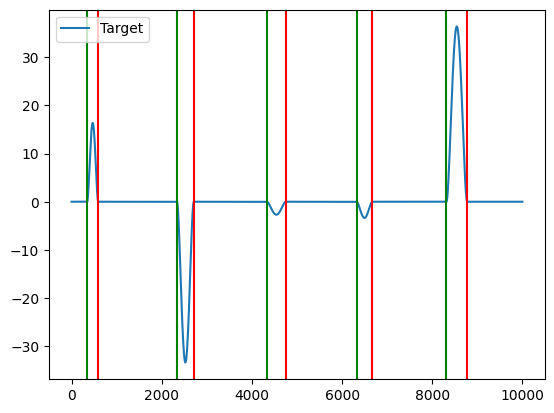

In [326]:
lower_bound = 0
upper_bound = 10000

joint_vels = sensor_data_np[:, -6:]
joint_vels = joint_vels.astype(np.float64)

end_indexes = determine_movement_ends(joint_vels, start_indexes)

print(start_indexes)
print(end_indexes)

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i, _ in enumerate(start_indexes):
    if lower_bound < start_indexes[i] < upper_bound:
        plt.axvline(start_indexes[i], color="g")
    if lower_bound < end_indexes[i] < upper_bound:
        plt.axvline(end_indexes[i], color="r")


plt.legend()

# Declaring data needed for training

We want to train a model to predict the time it takes to do a certain movement. Thus we now need to extract, the time a movement takes, and the start and end position

In [327]:
# Extract time
# This is easy as it is just the difference between the start and end timesteps of movements
start_positions = []
end_positions = []
movement_time = []

joint_positions = sensor_data_np[:, -12:-6]

for i, _ in enumerate(start_indexes):
    # Determine time taken
    time_taken = sensor_data_np[end_indexes[i], 2] - sensor_data_np[start_indexes[i], 2]
    movement_time.append(time_taken.total_seconds()) # save time taken in seconds

    # Extract start and end pos
    start_pos = joint_positions[start_indexes[i], :]
    start_positions.append(start_pos)

    end_pos = joint_positions[end_indexes[i], :]
    end_positions.append(end_pos)


print(f"{movement_time=}\n")
print(f"{start_positions=}\n")
print(f"{end_positions=}\n")

movement_time=[12.363682, 18.758488, 21.470137, 17.615013, 23.224391, 13.693861, 12.081563, 18.519413, 13.861068, 15.125784, 20.282981, 12.736104, 17.931537, 19.018492, 15.094958, 10.32841, 20.86838, 17.163936, 15.50909, 14.107404, 15.079149, 18.813821, 17.372228, 18.846995, 12.745159, 21.743915, 22.620911, 13.619402000000001, 11.687842, 7.281219, 19.674213, 18.608626, 22.748157, 20.621457, 12.748669, 1.25412, 1.650306, 1.9557820000000001, 1.5565280000000001, 1.3558729999999999, 2.001991]

start_positions=[array([-4.471744609213797e-07, -1.5700000767299953, 1.5699983137784814,
       -1.5699980659071837, -1.5700011438761456, -2.2674897461817574e-06],
      dtype=object), array([-12.080431789164868, 9.171684899364868, 7.159295563022158,
       -4.72858931467877, -0.1253470745246269, 8.724306130012884],
      dtype=object), array([0.2758132051277092, 11.926781695868813, -11.618136046619654,
       -0.2300079570791963, 6.914061130703854, -9.064374647858124],
      dtype=object), array([-8

In [328]:
start_positions[0]

array([-4.471744609213797e-07, -1.5700000767299953, 1.5699983137784814,
       -1.5699980659071837, -1.5700011438761456, -2.2674897461817574e-06],
      dtype=object)

In [329]:
end_positions[0]

array([-12.080425959178154, 9.171682055185231, 7.159298822676325,
       -4.7285886405098605, -0.12534869446369545, 8.724307397681098],
      dtype=object)

# Plot of correlation between the max distance a joint has to move and the time the movement takes.

In [330]:
max_position_diff = []

for i, _ in enumerate(start_positions):
    max_position_diff.append(np.max(np.abs(end_positions[i] - start_positions[i])))

max_position_diff

[12.080425512003693,
 18.777431763607925,
 21.60662128812956,
 17.546026742088067,
 23.374053257836216,
 13.49814959653552,
 11.825105168438569,
 18.503751746382406,
 13.650892781242801,
 14.960687279133413,
 20.35322771524774,
 12.477125812648678,
 17.855295609720848,
 19.03283115819409,
 14.933424260630904,
 9.974101730738468,
 20.917294640086947,
 17.114450556425574,
 15.346060242934865,
 13.892770288431151,
 14.891857845643496,
 18.780402370980084,
 17.310382788868917,
 18.817542024574113,
 12.499751701565831,
 21.85045460296076,
 22.699583571392647,
 13.35354163655272,
 11.387507072352877,
 6.770238888801197,
 19.73480641701387,
 18.63192687852053,
 22.89828682235129,
 20.707378462320687,
 12.469386807012086,
 0.5335827311411906,
 0.8806652481523041,
 1.2137379569908866,
 0.8270801135993239,
 0.6314817179290131,
 1.2959264388444272]

Text(0.5, 0, 'Max angle difference (rad)')

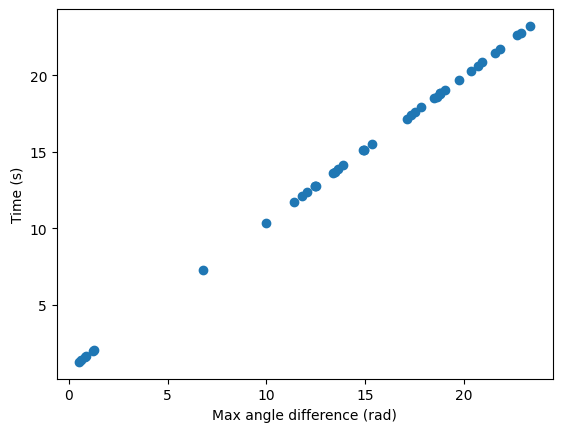

In [331]:
plt.scatter(max_position_diff, movement_time)
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")

## Proposing model

It seems we have a nice linear relationship. A linear regression model will do fine for fitting here!

Now we use the following approach for fitting the data:

$$Ax = b$$
$$\Updownarrow$$
$$x = A^{-1}b$$

Here $A$ contains the max joint position differences and a constant $1$, and $b$ contains the movement time.

In [332]:
A = np.vander(max_position_diff, 2)
b = np.array(movement_time)

x = np.linalg.pinv(A) @ b

x

array([0.95984308, 0.76497454])

We can now use the found coefficients $x_0$ and $x_1$ to make a model:

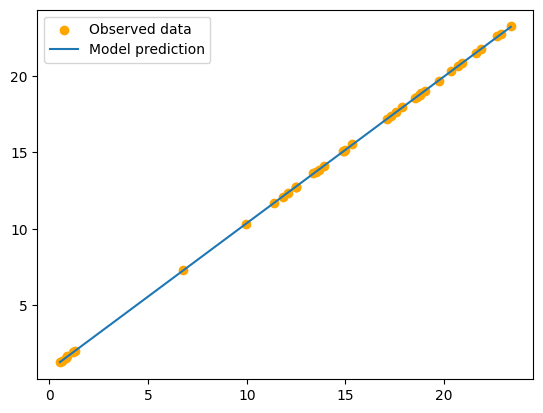

In [333]:
angle_space = np.linspace(np.min(max_position_diff), np.max(max_position_diff), 100)

# Feed through model
def linear_reg_model(n: np.ndarray, x: np.ndarray):
    n_vander = np.vander(n, 2)
    return n_vander @ x

time_spent_prediction = linear_reg_model(angle_space, x)

plt.scatter(max_position_diff, movement_time, color="orange", label="Observed data")
plt.plot(angle_space, time_spent_prediction, label="Model prediction")
plt.legend()